# SEIRS-SEI Malaria Model — Initial Condition Calibration

Calibrating E_H0, R_H0, and I_M0 to match the initial disease trend.

**Fixed**: I_H0 (from case data), M_0 ~ 10×N (from biting rate estimation), E_M0 ~ 3×I_M0 (equilibrium ratio)

**To calibrate**: E_H0 (exposed humans), R_H0 (recovered humans), I_M0 (infectious mosquitoes)

In [2]:
import sys
sys.path.append("..")

from ode_models.seirs_sei_ode_shared import *
%matplotlib inline

Data loaded and filtered successfully!
Climate data: 2556 days
Cases data: 2556 days
Pop data: 2556 days
Deforestation data: 3288 days
Forest fires data: 3288 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25
The initial ratio of exposed to infected mosquitos was estimated to be ~3
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=80342, E_M=2511, I_M=837


In [3]:
#### Yearly Simulation (2017-2023)
years = 2017 #list(range(2017, 2024))
all_results = []
current_state = initial_state_2017.copy()

start = f"{years}-01-01"
end = f"{years}-12-31"

USE_SMOOTH_CLIMATE = True

#### Simulation function with custom initial conditions
def run_simulation_with_IC(initial_state, M_prime_val=None):
    if M_prime_val is None:
        M_prime_val = M_prime
    state = initial_state.copy()
    all_IH = []
    all_dates = []
    N = round(pop_by_year[years])

    year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
    if USE_SMOOTH_CLIMATE:
            year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    num_days = len(year_climate)
    def ode_func(t, z):
        return seirs_sei_ode(t, z, N, year_climate,
                                T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                                c1, c2, D1, b1, b2, A, B, C, DD,
                                Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                                optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                                gamma, R_L, M_prime_val, tau_H, omega,
                                M_min=M_min, permanent_factor=permanent_factor, use_smooth_climate=USE_SMOOTH_CLIMATE)
    sol = solve_ivp(ode_func, [0, num_days], state,
                        t_eval=np.linspace(0, num_days, num_days*10), method='LSODA')
    if not sol.success:
        return np.array([]), np.array([])
    state = sol.y[:, -1].copy()
    state = np.maximum(state, 0)
    t_interp = np.linspace(0, sol.t[-1], len(year_climate))
    IH_interp = interp1d(sol.t, sol.y[2])(t_interp)
    all_IH.extend(IH_interp)
    all_dates.extend(year_climate['date'].values)
    
    return np.array(all_dates), np.array(all_IH)

In [4]:
rural_cases_df = rural_cases_df[(rural_cases_df['date'] >= start) & (rural_cases_df['date'] <= end)].reset_index(drop=True)
rural_cases_df['date'] = pd.to_datetime(rural_cases_df['date'])

In [5]:
#### Baseline: current initial conditions
dates_base, IH_base = run_simulation_with_IC(initial_state_2017)
baseline_mse = np.mean((IH_base - rural_cases_df['active_total'].values) ** 2)
print(f"Baseline MSE (current ICs): {baseline_mse:,.2f}")
print(f"  S_H0={S_H0}, E_H0={E_H0}, I_H0={I_H0}, R_H0={R_H0}")
print(f"  S_M0={S_M0}, E_M0={E_M0}, I_M0={I_M0}")

Baseline MSE (current ICs): 969,094.00
  S_H0=5752, E_H0=418, I_H0=944, R_H0=1255
  S_M0=80342, E_M0=2511, I_M0=837


In [6]:
#### Objective function for IC calibration
# Params: [E_H0_frac, R_H0_frac, I_M0_ratio]
# E_H0_frac = E_H0 / N_2017
# R_H0_frac = R_H0 / N_2017
# I_M0_ratio = I_M0 / M_0

def objective_IC(params):
    E_H0_frac, R_H0_frac, I_M0_ratio = params
    
    E_H0 = round(E_H0_frac * N_2017)
    R_H0 = round(R_H0_frac * N_2017)
    I_M0 = round(I_M0_ratio * M_0)
    
    if E_H0 + I_H0 + R_H0 > N_2017:
        return 1e15
    if I_M0 > M_0 / 4:
        return 1e15
    
    S_H0 = N_2017 - E_H0 - I_H0 - R_H0
    if S_H0 < 0:
        return 1e15
    
    E_M0 = round(3 * I_M0)
    S_M0 = M_0 - E_M0 - I_M0
    if S_M0 < 0:
        return 1e15
    
    init_state = np.array([S_H0, E_H0, I_H0, R_H0, S_M0, E_M0, I_M0])
    dates, IH = run_simulation_with_IC(init_state)
    
    if len(dates) == 0:
        return 1e15
    
    model_interp = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    obs_dates_int = rural_cases_df['date'].astype(np.int64).values
    model_at_obs = model_interp(obs_dates_int)
    observed = rural_cases_df['active_total'].values
    mse = np.mean((model_at_obs - observed) ** 2)
    return mse

In [7]:
#### Grid search over initial condition parameters
# Ranges:
#   E_H0_frac:  0.01 to 0.20  (1% to 20% of N)
#   R_H0_frac:  0.05 to 0.50  (5% to 50% of N)
#   I_M0_ratio: 0.001 to 0.05 (0.1% to 5% of M_0)

E_H0_candidates = [0.01, 0.03, 0.05, 0.08, 0.12, 0.18]
R_H0_candidates = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40]
I_M0_candidates = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]

print("Grid search for initial conditions...")
print(f"Grid size: {len(E_H0_candidates)} x {len(R_H0_candidates)} x {len(I_M0_candidates)} = {len(E_H0_candidates)*len(R_H0_candidates)*len(I_M0_candidates)}")

best_params = None
best_mse = 1e15
results = []

for eh in E_H0_candidates:
    for rh in R_H0_candidates:
        for im in I_M0_candidates:
            if eh + I_H0/N_2017 + rh > 1.0:
                continue
            mse = objective_IC([eh, rh, im])
            results.append((eh, rh, im, mse))
            if mse < best_mse:
                best_mse = mse
                best_params = (eh, rh, im)
            print(f"  E_H0={eh:.2f}, R_H0={rh:.2f}, I_M0={im:.3f} -> MSE={mse:>12,.2f}")

print(f"\nBest from grid:")
print(f"  E_H0_frac = {best_params[0]:.2f}  ({round(best_params[0]*N_2017)} people)")
print(f"  R_H0_frac = {best_params[1]:.2f}  ({round(best_params[1]*N_2017)} people)")
print(f"  I_M0_ratio = {best_params[2]:.3f} ({round(best_params[2]*M_0)} mosquitos)")
print(f"  MSE = {best_mse:,.2f}")

Grid search for initial conditions...
Grid size: 6 x 6 x 6 = 216
  E_H0=0.01, R_H0=0.05, I_M0=0.001 -> MSE=1,066,634.61
  E_H0=0.01, R_H0=0.05, I_M0=0.002 -> MSE=1,055,170.23
  E_H0=0.01, R_H0=0.05, I_M0=0.005 -> MSE=1,024,961.00
  E_H0=0.01, R_H0=0.05, I_M0=0.010 -> MSE=  984,428.58
  E_H0=0.01, R_H0=0.05, I_M0=0.020 -> MSE=  939,263.34
  E_H0=0.01, R_H0=0.05, I_M0=0.050 -> MSE=1,021,116.96
  E_H0=0.01, R_H0=0.10, I_M0=0.001 -> MSE=1,078,404.69
  E_H0=0.01, R_H0=0.10, I_M0=0.002 -> MSE=1,067,679.15
  E_H0=0.01, R_H0=0.10, I_M0=0.005 -> MSE=1,038,526.46
  E_H0=0.01, R_H0=0.10, I_M0=0.010 -> MSE=  999,010.28
  E_H0=0.01, R_H0=0.10, I_M0=0.020 -> MSE=  952,853.55
  E_H0=0.01, R_H0=0.10, I_M0=0.050 -> MSE=1,005,125.52
  E_H0=0.01, R_H0=0.15, I_M0=0.001 -> MSE=1,090,556.89
  E_H0=0.01, R_H0=0.15, I_M0=0.002 -> MSE=1,080,434.28
  E_H0=0.01, R_H0=0.15, I_M0=0.005 -> MSE=1,052,965.12
  E_H0=0.01, R_H0=0.15, I_M0=0.010 -> MSE=1,014,887.05
  E_H0=0.01, R_H0=0.15, I_M0=0.020 -> MSE=  966,984.94


In [8]:
#### Fine optimization with L-BFGS-B
from scipy.optimize import minimize

print("Fine optimization with L-BFGS-B...")

initial_guess = [best_params[0], best_params[1], best_params[2]]
bounds = [(0.005, 0.25), (0.02, 0.55), (0.0005, 0.06)]

result = minimize(
    objective_IC,
    initial_guess,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 50, 'ftol': 1e-6}
)

opt_eh, opt_rh, opt_im = result.x
opt_E_H0 = round(opt_eh * N_2017)
opt_R_H0 = round(opt_rh * N_2017)
opt_I_M0 = round(opt_im * M_0)
opt_E_M0 = round(3 * opt_I_M0)
opt_S_H0 = N_2017 - opt_E_H0 - I_H0 - opt_R_H0
opt_S_M0 = M_0 - opt_E_M0 - opt_I_M0

print(f"Optimized ICs (MSE = {result.fun:,.2f}):")
print(f"  S_H0 = {opt_S_H0}, E_H0 = {opt_E_H0}, I_H0 = {I_H0}, R_H0 = {opt_R_H0}")
print(f"  S_M0 = {opt_S_M0}, E_M0 = {opt_E_M0}, I_M0 = {opt_I_M0}")
print(f"  (E_H0_frac={opt_eh:.3f}, R_H0_frac={opt_rh:.3f}, I_M0_ratio={opt_im:.4f})")

Fine optimization with L-BFGS-B...
Optimized ICs (MSE = 937,019.00):
  S_H0 = 6756, E_H0 = 251, I_H0 = 944, R_H0 = 418
  S_M0 = 76994, E_M0 = 5022, I_M0 = 1674
  (E_H0_frac=0.030, R_H0_frac=0.050, I_M0_ratio=0.0200)


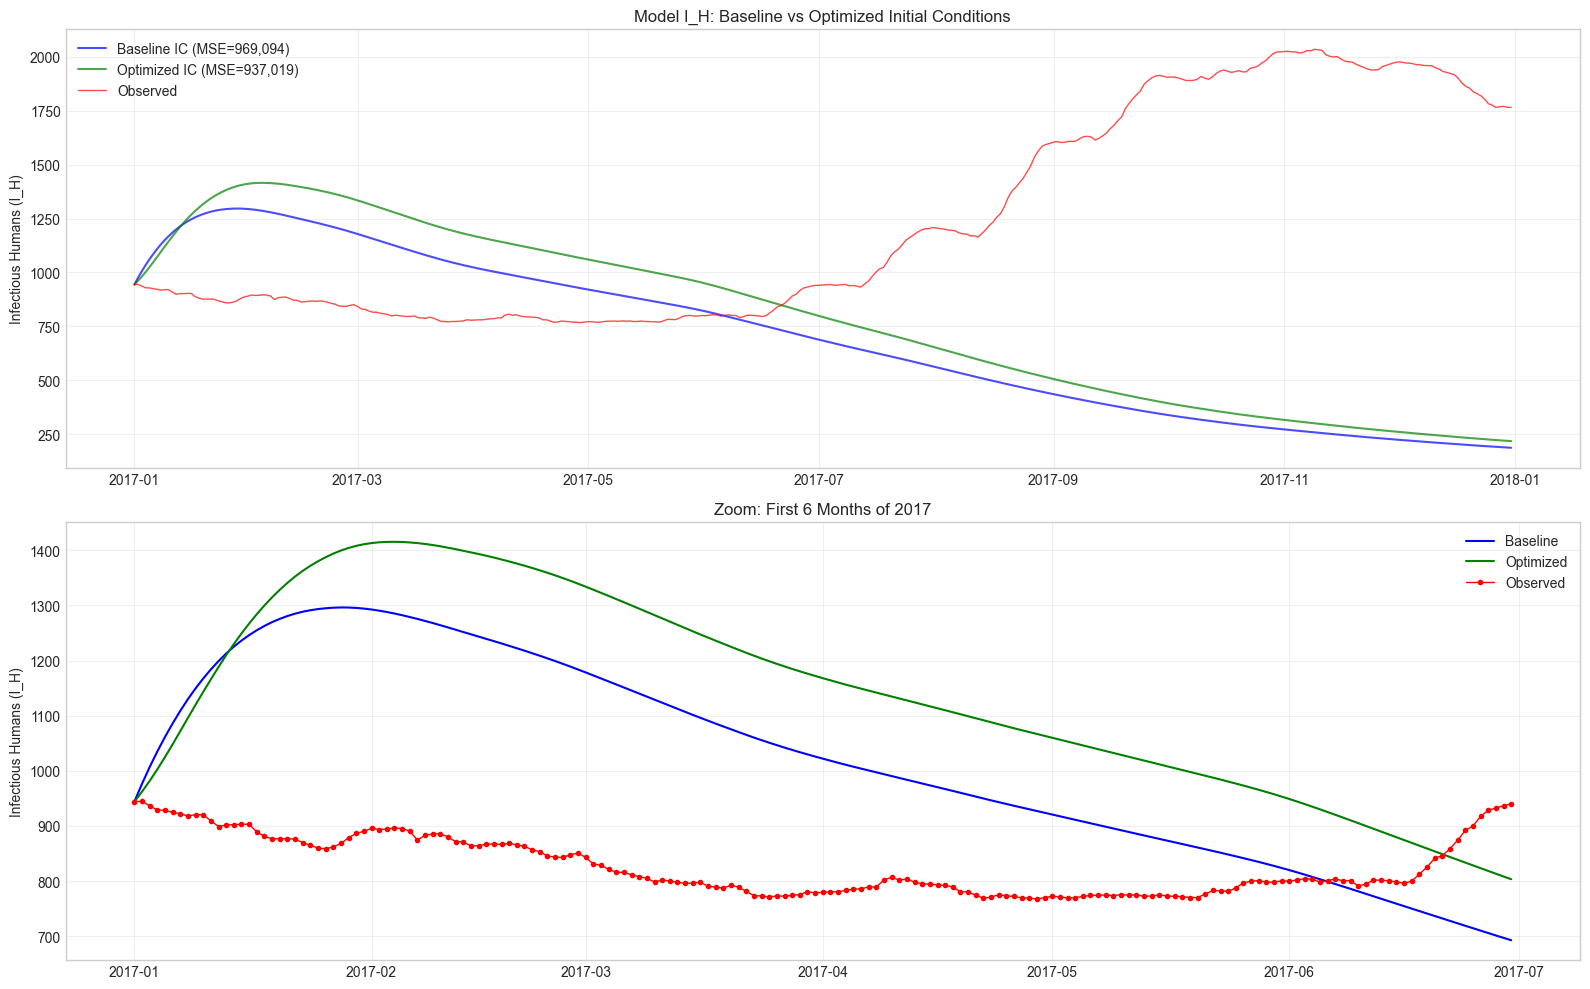

In [9]:
#### Compare baseline vs optimized ICs
opt_init_state = np.array([opt_S_H0, opt_E_H0, I_H0, opt_R_H0, opt_S_M0, opt_E_M0, opt_I_M0])
dates_opt, IH_opt = run_simulation_with_IC(opt_init_state)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax1 = axes[0]
ax1.plot(pd.to_datetime(dates_base), IH_base, 'b-', linewidth=1.5, alpha=0.7, label=f'Baseline IC (MSE={baseline_mse:,.0f})')
ax1.plot(pd.to_datetime(dates_opt), IH_opt, 'g-', linewidth=1.5, alpha=0.7, label=f'Optimized IC (MSE={result.fun:,.0f})')
ax1.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax1.set_ylabel('Infectious Humans (I_H)')
ax1.set_title('Model I_H: Baseline vs Optimized Initial Conditions')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
# Zoom to first 180 days
mask_base = pd.to_datetime(dates_base) < pd.to_datetime('2017-07-01')
mask_opt = pd.to_datetime(dates_opt) < pd.to_datetime('2017-07-01')
mask_obs = rural_cases_df['date'] < pd.to_datetime('2017-07-01')
ax2.plot(pd.to_datetime(dates_base)[mask_base], IH_base[mask_base], 'b-', linewidth=1.5, label='Baseline')
ax2.plot(pd.to_datetime(dates_opt)[mask_opt], IH_opt[mask_opt], 'g-', linewidth=1.5, label='Optimized')
ax2.plot(rural_cases_df['date'][mask_obs], rural_cases_df['active_total'][mask_obs], 'ro-', markersize=3, linewidth=1.0, label='Observed')
ax2.set_ylabel('Infectious Humans (I_H)')
ax2.set_title('Zoom: First 6 Months of 2017')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()